In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q spacy
!pip install -q

ERROR: You must give at least one requirement to install (see "pip help install")


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string

import tensorflow as tf
import tensorflow.keras as keras
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [31]:
import nltk# ПОПРОБОВАТЬ RAZDEL

nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
df = pd.read_csv("3rd_dataset.csv")
#df = pd.read_csv(r'/content/drive/MyDrive/ML-edu/AI_ML_DC/module2/ИИ_и_МО_Модуль_2_Лабораторная_работа_6/3rd_dataset.csv')

In [5]:
df['category'].unique()

array(['Автоматика. Вычислительная техника', 'Астрономия', 'Биология',
       'Биотрехнология', 'Внешняя торговля'], dtype=object)

In [7]:
#raw_ru = 'АЛГОРИТМ МАРКИРОВАНИЯ ТЕКСТОВЫХ ДОКУМЕНТОВ НА ОСНОВЕ ИЗМЕНЕНИЯ ИНТЕРВАЛОВ МЕЖДУ СЛОВАМИ, ОБЕСПЕЧИВАЮЩИЙ УСТОЙЧИВОСТЬ К ПРЕОБРАЗОВАНИЮ ФОРМАТА'
#nlp = spacy.load('ru_core_news_lg')
#spacy_results = nlp(raw_ru)

In [4]:
df

,title,category
0,СРАВНЕНИЕ СИСТЕМЫ ОБНАРУЖЕНИЯ ВТОРЖЕНИЙ НА ОСН...,Автоматика. Вычислительная техника
1,ОПРЕДЕЛЕНИЕ ВЛИЯТЕЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ СОЦИАЛЬН...,Автоматика. Вычислительная техника
2,АЛГОРИТМ МАРКИРОВАНИЯ ТЕКСТОВЫХ ДОКУМЕНТОВ НА ...,Автоматика. Вычислительная техника
3,СРЕДСТВА ЗАХВАТА И ОБРАБОТКИ ВЫСОКОСКОРОСТНОГО...,Автоматика. Вычислительная техника
4,ИННОВАЦИОННЫЙ ПОДХОД К АВТОМАТИЗИРОВАННОЙ ФОТО...,Автоматика. Вычислительная техника
...,...,...
189,ЭКОНОМИЧЕСКИЕ И ТЕХНОЛОГИЧЕСКИЕ ФАКТОРЫ РАЗВИТ...,Внешняя торговля
190,ПРОБЛЕМЫ УЧАСТИЯ РОССИИ В ОСВОЕНИИ НЕФТЕГАЗОВЫ...,Внешняя торговля
191,РОССИЙСКИЕ ТРАНСНАЦИОНАЛЬНЫЕ КОРПОРАЦИИ НА МЕЖ...,Внешняя торговля
192,ВНЕШНЯЯ ТОРГОВЛЯ РОССИИ УСЛУГАМИ,Внешняя торговля


<Axes: xlabel='category', ylabel='Count'>

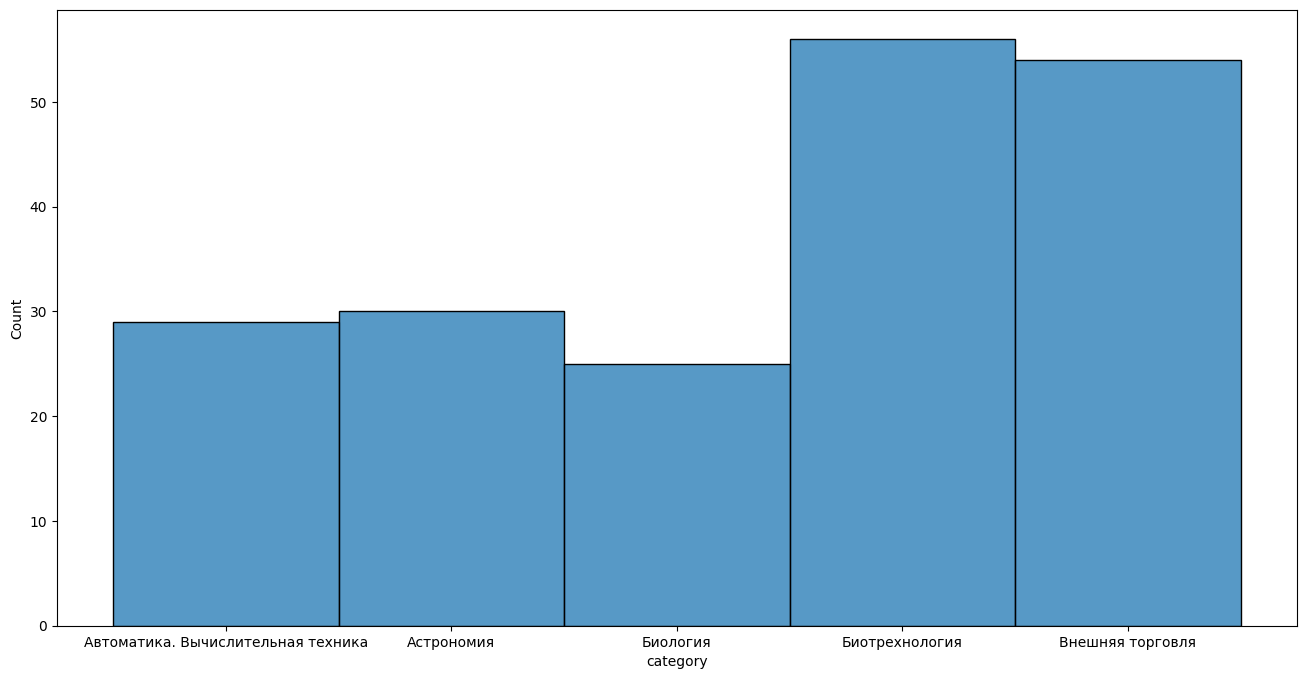

In [38]:
plt.figure(figsize=(16,8))
sns.histplot(df['category'])

In [24]:
def preprocess_y(y, label_encoder=None):
      if label_encoder is None:
        label_encoder = LabelEncoder().fit(y)

      y_encoded = label_encoder.transform(y)

      return y_encoded, label_encoder

def preprocess_X(X, tokenizer=None):
    new_X = []
    for i,text in enumerate(X):
        text = text.translate(str.maketrans('', '', string.punctuation)).lower()
        tokens = word_tokenize(text) #токенизация

        stop_words = set(stopwords.words('russian'))
        tokens = [word for word in tokens if word not in stop_words] #убираем стоп слова

        stemmer = SnowballStemmer("russian")
        tokens = [stemmer.stem(word) for word in tokens] # стемминг

        new_X.append(' '.join(tokens))

    if tokenizer is None:
      tokenizer = Tokenizer()
      tokenizer.fit_on_texts(new_X)

    X_seq = tokenizer.texts_to_sequences(new_X)

    max_length = max(len(x) for x in X_seq)
    X_pad = pad_sequences(X_seq, maxlen=max_length, padding='post')

    return X_pad, max_length, tokenizer

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df['title'], df['category'], test_size=0.2, random_state=42)

In [27]:

X_train, max_length, tokenizer = preprocess_X(X_train)
y_train, label_encoder = preprocess_y(y_train)


In [14]:
X_test_proc, _, _ = preprocess_X(X_test, tokenizer=tokenizer)
y_test_proc, l = preprocess_y(y_test, label_encoder=label_encoder)

In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.3478260869565217), 1: np.float64(1.1481481481481481), 2: np.float64(1.7222222222222223), 3: np.float64(0.7209302325581395), 4: np.float64(0.7045454545454546)}


In [28]:
model = Sequential(
    [
        Embedding(input_dim=1000, output_dim=128, input_length=max_length),
        Bidirectional(LSTM(128, activation='tanh')),
        Dropout(0.4),
        Dense(5, activation='softmax')
    ]
)

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    class_weight=class_weights_dict, )

loss, accuracy = model.evaluate(X_test_proc, y_test_proc)
print(f'Accuracy: {accuracy * 100:.2f}%')

Epoch 1/50


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.1391 - loss: 1.7076 - val_accuracy: 0.0645 - val_loss: 1.6394
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1478 - loss: 1.6310 - val_accuracy: 0.1613 - val_loss: 1.6199
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4180 - loss: 1.6090 - val_accuracy: 0.2581 - val_loss: 1.5996
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5812 - loss: 1.5478 - val_accuracy: 0.4516 - val_loss: 1.5680
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7057 - loss: 1.4379 - val_accuracy: 0.1613 - val_loss: 1.6570
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6566 - loss: 1.3249 - val_accuracy: 0.4516 - val_loss: 1.4335
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8062 - loss: 0.9629 - val_accuracy: 0.5484 - val_loss: 1.1975
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7818 - loss: 0.8669 - val_accuracy: 0.5484 - val_loss: 1.3000
Epoch 9/50


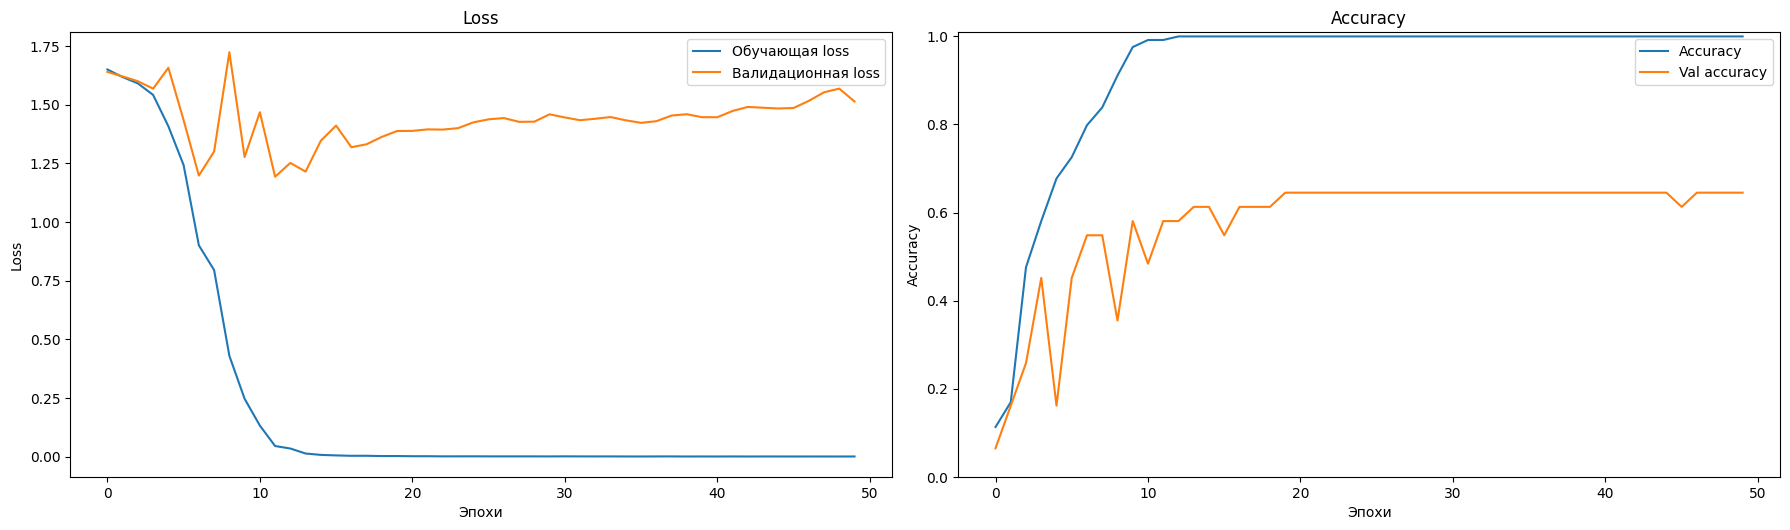

In [29]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()

In [27]:
test,_ ,_ = preprocess_X(['река бобер гриб дерево дождь здоровье'], tokenizer=tokenizer)

predicted = model.predict(test)
predicted_category = label_encoder.inverse_transform([predicted.argmax()])

print(f'Predicted category: {predicted_category[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Predicted category: Биология


In [21]:
test,_ ,_ = preprocess_X(['солнце марс система планета звезда'], tokenizer=tokenizer)

predicted = model.predict(test)
predicted_category = label_encoder.inverse_transform([predicted.argmax()])

print(f'Predicted category: {predicted_category[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted category: Астрономия


In [22]:
label_encoder.classes_

array(['Автоматика. Вычислительная техника', 'Астрономия', 'Биология',
       'Биотрехнология', 'Внешняя торговля'], dtype=object)

In [23]:
predicted = model.predict(X_test_proc)
for text, pred, y_true in zip(X_test, predicted, y_test):
  predicted_category = label_encoder.inverse_transform([pred.argmax()])
  f = ('+' if y_true==predicted_category else '-')
  print(y_true)
  print(f'{f} {text} =:= {predicted_category[0]}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Биотрехнология
+ ЭКСПЕРИМЕНТАЛЬНОЕ ОПРЕДЕЛЕНИЕ ПАРАМЕТРОВ ХВОЙНОГО ЛЕЧЕБНОГО ЭКСТРАКТА, НЕОБХОДИМЫХ ДЛЯ ОПТИМИЗАЦИИ ПРОЦЕССА КОНЦЕНТРИРОВАНИЯ В РОТОРНО-ВАКУУМНОМ ПЛЕНОЧНОМ ИСПАРИТЕЛЕ =:= Биотрехнология
Автоматика. Вычислительная техника
+ ИНФОРМАЦИОННАЯ ТЕХНОЛОГИЯ ОБРАБОТКИ ДАННЫХ ДЗЗ ДЛЯ ОЦЕНКИ АРЕАЛОВ РАСТЕНИЙ =:= Автоматика. Вычислительная техника
Внешняя торговля
- ОЦЕНКА НАЛИЧИЯ ОСНОВНЫХ ФОНДОВ В РФ ПО УЧЕТНОЙ СТОИМОСТИ С 2000 ПО 2014 ГОД =:= Астрономия
Биотрехнология
- ГЕН ROLC АГРОБАКТЕРИЙ: НА ПУТИ К ПОНИМАНИЮ ФУНКЦИИ =:= Астрономия
Биология
- АНТАГОНИСТИЧЕСКИЙ ПОТЕНЦИАЛ СИБИРСКИХ ШТАММОВ BACILLUS SPP. В ОТНОШЕНИИ ВОЗБУДИТЕЛЕЙ БОЛЕЗНЕЙ ЖИВОТНЫХ И РАСТЕНИЙ =:= Астрономия
Внешняя торговля
+ ПРАВИЛА ВСЕМИРНОЙ ТОРГОВОЙ ОРГАНИЗАЦИИ И ПРОТЕКЦИОНИЗМ В ОБЛАСТИ ВОЗОБНОВЛЯЕМЫХ ИСТОЧНИКОВ ЭНЕРГИИ" =:= Внешняя торговля
Астрономия
+ МАГНИТНЫЕ СР-ЗВЕЗДЫ ГЛАВНОЙ ПОСЛЕДОВАТЕЛЬНОСТИ П. ФИЗИЧЕСКИЕ ПАРАМЕТРЫ И ХИМИЧЕСКИЙ СОСТАВ АТМОСФЕР =:= Астрономия
Автомати